<a href="https://colab.research.google.com/github/Doctor-Math/Analise-Exploratoria-e-Preditiva-da-Economia-Brasileira/blob/main/Report_code/Balancing_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Instalando bibliotecas

In [1]:
pip install tomotopy # Para usar o Guided LDA

In [2]:
pip install leia-br scikit-learn pandas

In [3]:
pip install datasets==2.18.0

In [4]:
pip install gensim

In [5]:
import pandas as pd
import numpy as np
import ast # Converter as 'strings' do df para 'listas de strings'
import tomotopy as tp # Para uso do GuidedLDA
import torch
import gc # 'Garbage collector', para limpar a memória RAM a cada iteração (Bert é pesado)

from datasets import Dataset
from LeIA import SentimentIntensityAnalyzer # Classificador LeIA
from sklearn.metrics import accuracy_score, classification_report # Para a matriz de confusão e outras métricas
from sklearn.model_selection import train_test_split # Para estratificação dos dados
from sklearn.metrics import f1_score # F1-Macro
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity # Para cálculo do score do eixo semântico



from gensim.models import KeyedVectors


In [6]:
# Dando permissão para o Colab "enxergar" as pastas do Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Gerando amostras balanceadas das bases (treino e teste)

In [7]:
B2W_treino=pd.read_csv('/content/drive/MyDrive/b2w_treino.csv')
B2W_teste=pd.read_csv('/content/drive/MyDrive/b2w_teste.csv')

In [8]:
B2W_treino

,review_text,polarity
0,ótimo produto. Custo desempenho excelente. Pra...,1
1,Nao tem uma boa sugoçào .o cheiro fica no apar...,0
2,"Sei que é um colchão barato, mas surpreendeu d...",0
3,Devia te mais em fomacao queria para o j5 prim...,0
4,"infelismente nao posso avaliar este produto , ...",0
...,...,...
57207,A água fica bem geladinha (apesar de demorar u...,1
57208,"CELULAR EXCELENTE, MUITO PRÁTICO E FÁCIL DE US...",1
57209,Cabelo ficou pior com ele do que sem. Não sei ...,0
57210,Ótimo produto e preço! Aegwrhetjryjyjw5uj4j...,1


In [9]:
df_pos=B2W_treino[B2W_treino['polarity']==1]
df_neg=B2W_treino[B2W_treino['polarity']==0]

In [10]:
n_treino=len(B2W_treino)//2 # Quantidade de pos/neg na base de treino

props=[(0.5,0.5),(0.6,0.4),(0.7,0.3),(0.8, 0.2),(0.9,0.1)]

treinos = {}

for pos_prop, neg_prop in props:
  n_pos=int(pos_prop*n_treino)
  n_neg=int(neg_prop*n_treino)

  pos_amostra=df_pos.sample(n=n_pos, random_state=42)
  neg_amostra=df_neg.sample(n=n_neg, random_state=42)

  df_treino = pd.concat([pos_amostra, neg_amostra]).sample(frac=1, random_state=42) # Juntar e embaralhar
  treinos[(pos_prop,neg_prop)] = df_treino


## Preparando os modelos

### Preparando os modelos semi-supervisionados

**Guided LDA**

In [11]:
# Seed words
seed_words ={
    1:['bom', 'boa', 'ótimo', 'ótima', 'feliz', 'bonito', 'bonita', 'lindo', 'linda', 'maravilhoso', 'maravilhosa',
    'excelente', 'top', 'adoro', 'adorei', 'adorar', 'amei', 'amo', 'amar', 'legal', 'perfeito', 'perfeita', 'incrível',
    'espetacular', 'parabéns', 'sucesso', 'maravilha', 'curti', 'interessante',
    'divertido', 'foda', 'massa', 'show', 'agradável', 'brilhante', 'viva', 'vitoria',
    'alegria', 'amamos', 'adoramos', 'encantado', 'apaixonado', 'entusiasmado', 'sensacional',
    'formidável', 'genial', 'positivo', 'ganhou', 'venceu', 'melhor'],

    0:['ruim', 'péssimo', 'péssima', 'triste', 'horrível', 'desastroso', 'odiei', 'odeio', 'ódio', 'lixo',
    'bosta', 'horroroso', 'horrorosa', 'feio', 'feia', 'chato', 'chata', 'ridículo',
    'ridícula', 'erro', 'fracasso', 'pavoroso', 'merda', 'maldito', 'nojento',
    'podre', 'vergonha', 'bosta', 'pior', 'detesto', 'terrível', 'ruindade',
    'tristeza', 'morte', 'derrota', 'negativo', 'bosta', 'porcaria', 'fraco', 'fraca',
    'horrendo', 'escroto', 'lamentável', 'absurdo', 'crime']
}

In [12]:
def treinar_glda(textos, seeds, n_topicos):
    mdl = tp.LDAModel(k=n_topicos)

    # Para cada tópico no dicionário de sementes:
    for topic_id, words in seeds.items():
        for word in words:
            # Isso força a palavra a ter um peso muito maior no tópico escolhido
            mdl.set_word_prior(word, {topic_id: 1.0})

    # Adiciona os documentos
    for doc in textos:
        mdl.add_doc(doc)

    # Treina o modelo
    mdl.train(200)
    return mdl

In [13]:
def prever_glda(modelo, textos_teste):
    predicoes = []

    for doc in textos_teste:
        # 1. Converte o texto em um documento que o Tomotopy entende
        # Importante: usar o mesmo split/tokenização do treino
        instancia = modelo.make_doc(doc)

        # 2. Realiza a inferência (não altera o modelo, apenas calcula)
        # 'iter=100' é o padrão para garantir convergência na predição
        topicos_dist, log_ll = modelo.infer(instancia,100)

        # 3. Pega o índice do tópico com maior probabilidade (ex: 0 ou 1)
        classe_predita = np.argmax(topicos_dist)
        predicoes.append(classe_predita)

    return predicoes

In [26]:
def calcular_metricas(y_test, y_pred):
     return {
        "acuracia": accuracy_score(y_test, y_pred),
        "precisao": precision_score(y_test, y_pred, average=None),
        "revocacao": recall_score(y_test, y_pred, average=None),
        "f1": f1_score(y_test, y_pred, average="weighted")
    }


**Semantic-Axis**

In [15]:
# O gensim descompacta o .gz em tempo de execução
model = KeyedVectors.load("/content/drive/MyDrive/fasttext_pt.kv")

print("Modelo carregado com sucesso!")

Modelo carregado com sucesso!


In [16]:
pos_words = [
    'bom', 'boa', 'ótimo', 'ótima', 'feliz', 'bonito', 'lindo', 'maravilhoso', 'maravilhosa',
    'excelente', 'top', 'adoro', 'amei', 'legal', 'perfeito', 'perfeita', 'incrível',
    'espetacular', 'parabéns', 'sucesso', 'maravilha', 'curti', 'interessante',
    'divertido', 'foda', 'massa', 'show', 'agradável', 'brilhante', 'viva', 'vitoria',
    'alegria', 'amamos', 'adoramos', 'encantado', 'apaixonado', 'sensacional',
    'formidável', 'genial', 'positivo', 'ganhou', 'venceu', 'melhor'
]

neg_words = [
    'ruim', 'péssimo', 'péssima', 'triste', 'horrível', 'desastroso', 'odiei', 'lixo',
    'bosta', 'horroroso', 'horrorosa', 'feio', 'feia', 'chato', 'chata', 'ridículo',
    'ridícula', 'erro', 'fracasso', 'pavoroso', 'merda', 'maldito', 'nojento',
    'podre', 'vergonha', 'bosta', 'pior', 'odiei', 'detesto', 'terrível', 'ruindade',
    'tristeza', 'morte', 'derrota', 'negativo', 'bosta', 'porcaria', 'fraco',
    'horrendo', 'escroto', 'lamentável', 'absurdo', 'crime'
]

# Garantindo que as palavras existam no vocabulário do FastText
pos_vectors = [model[w] for w in pos_words if w in model]
neg_vectors = [model[w] for w in neg_words if w in model]

print(f"Âncoras Positivas: {len(pos_vectors)} | Negativas: {len(neg_vectors)}")

# Calculando os centroides com a base expandida
pos_anchor = np.mean(pos_vectors, axis=0)
neg_anchor = np.mean(neg_vectors, axis=0)

# O Eixo Refinado (Direção do Sentimento)
eixo = pos_anchor - neg_anchor


Âncoras Positivas: 43 | Negativas: 43


In [32]:
import re

# Função de tokenização simples
def limpar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto, flags=re.MULTILINE) # remove links
    texto = re.sub(r'@\w+', '', texto) # remove menções @user
    texto = re.sub(r'#\w+', '', texto) # remove hashtags (opcional)
    return texto

# Lista de palavras que não agregam sentimento
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
# Para simplicidade, vamos usar uma lista manual básica das mais comuns:
stopwords_pt = {'a', 'o', 'e', 'do', 'da', 'no', 'na', 'de', 'que', 'um', 'uma', 'os', 'as', 'com', 'em'}

def refinar_vetor(texto):
    texto = limpar_texto(texto)
    palavras = texto.split()
    # Filtramos as stopwords e garantimos que a palavra existe no modelo
    vetores = [model[p] for p in palavras if p in model and p not in stopwords_pt]

    if not vetores:
        # Se o tweet só sobrar stopwords, tentamos usar o tweet completo como fallback
        vetores = [model[p] for p in palavras if p in model]
        if not vetores: return np.zeros(300)

    return np.mean(vetores, axis=0)



# Aplicando a nova vetorização
X_vetorizado = np.array([refinar_vetor(t) for t in B2W_teste['review_text']])



# Similaridade de cosseno
scores = cosine_similarity(X_vetorizado, eixo.reshape(1, -1)).flatten()

y_pred_eixo = (scores > 0).astype(int)



### Preparando os modelos supervisionados clássicos

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB

modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000),
    "Floresta Aleatória": RandomForestClassifier(),
    "Árvore de Decisão": DecisionTreeClassifier(),
    "Naive Bayes": MultinomialNB()
}

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def avaliar_modelo(modelo, X_train, y_train, X_test, y_test):

    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    return {
        "acuracia": accuracy_score(y_test, y_pred),
        "precisao": precision_score(y_test, y_pred, average=None),
        "revocacao": recall_score(y_test, y_pred, average=None),
        "f1": f1_score(y_test, y_pred, average="weighted")
    }

In [20]:
vetorizador = TfidfVectorizer(max_features=10000)

In [35]:
resultados = []

X_teste=B2W_teste['review_text']
y_teste=B2W_teste['polarity']

X_teste = X_teste.apply(limpar_texto)

# Itera sobre as proporções
for nome_exp, treino in treinos.items():
  X_treino=treino['review_text']
  y_treino=treino['polarity']

  X_treino = X_treino.apply(limpar_texto)

  # Modelos semi-supervisionados
  # LDA
  X_treino_tokens = X_treino.apply(lambda x: x.split())
  X_teste_tokens = X_teste.apply(lambda x: x.split())

  mdl_treinado=treinar_glda(X_treino_tokens,seed_words,2)
  y_pred_glda = prever_glda(mdl_treinado, X_teste_tokens)
  metricas=calcular_metricas(y_teste,y_pred_glda)

  resultados.append({
        "prop": nome_exp,
        "modelo": 'LDA',
        **metricas
        })

  # Semantic-Axis

  metricas=calcular_metricas(y_teste,y_pred_eixo)

  resultados.append({
        "prop": nome_exp,
        "modelo": 'Semantic-Axis',
        **metricas
        })

  # Vetorização com TF-IDF
  X_treino_vec = vetorizador.fit_transform(X_treino)
  X_teste_vec = vetorizador.transform(X_teste)

  # Itera sobre os modelos supervisionados
  for nome, modelo in modelos.items():

    # Modelos supervisionados clássicos
    metricas = avaliar_modelo(modelo, X_treino_vec, y_treino, X_teste_vec, y_teste)

    resultados.append({
        "prop": nome_exp,
        "modelo": nome,
        **metricas
        })

/usr/local/lib/python3.12/dist-packages/tomotopy/models.py:637: RuntimeWarning: The training result may differ even with fixed seed if `workers` != 1.
  return self._train(iterations, workers, parallel, freeze_topics, callback_interval, callback)
/usr/local/lib/python3.12/dist-packages/tomotopy/models.py:637: RuntimeWarning: The training result may differ even with fixed seed if `workers` != 1.
  return self._train(iterations, workers, parallel, freeze_topics, callback_interval, callback)
/usr/local/lib/python3.12/dist-packages/tomotopy/models.py:637: RuntimeWarning: The training result may differ even with fixed seed if `workers` != 1.
  return self._train(iterations, workers, parallel, freeze_topics, callback_interval, callback)
/usr/local/lib/python3.12/dist-packages/tomotopy/models.py:637: RuntimeWarning: The training result may differ even with fixed seed if `workers` != 1.
  return self._train(iterations, workers, parallel, freeze_topics, callback_interval, callback)
/usr/local/l

/usr/local/lib/python3.12/dist-packages/tomotopy/models.py:637: RuntimeWarning: The training result may differ even with fixed seed if `workers` != 1.
  return self._train(iterations, workers, parallel, freeze_topics, callback_interval, callback)


In [36]:
df_resultados = pd.DataFrame(resultados)
print(df_resultados)

          prop               modelo  acuracia  \
0   (0.5, 0.5)                  LDA  0.823406   
1   (0.5, 0.5)        Semantic-Axis  0.777754   
2   (0.5, 0.5)  Regressão Logística  0.935892   
3   (0.5, 0.5)   Floresta Aleatória  0.916387   
4   (0.5, 0.5)    Árvore de Decisão  0.866751   
5   (0.5, 0.5)          Naive Bayes  0.921211   
6   (0.6, 0.4)                  LDA  0.844589   
7   (0.6, 0.4)        Semantic-Axis  0.777754   
8   (0.6, 0.4)  Regressão Logística  0.934004   
9   (0.6, 0.4)   Floresta Aleatória  0.913521   
10  (0.6, 0.4)    Árvore de Decisão  0.866331   
11  (0.6, 0.4)          Naive Bayes  0.915338   
12  (0.7, 0.3)                  LDA  0.853747   
13  (0.7, 0.3)        Semantic-Axis  0.777754   
14  (0.7, 0.3)  Regressão Logística  0.919533   
15  (0.7, 0.3)   Floresta Aleatória  0.895134   
16  (0.7, 0.3)    Árvore de Decisão  0.854796   
17  (0.7, 0.3)          Naive Bayes  0.893946   
18  (0.8, 0.2)                  LDA  0.840115   
19  (0.8, 0.2)      

In [37]:
df_resultados.to_csv('resultados_experimento_balanceamento.csv',index=False)

In [39]:
df_resultados

,prop,modelo,acuracia,precisao,revocacao,f1
0,"(0.5, 0.5)",LDA,0.823406,"[0.8439916716240333, 0.8051451187335092]","[0.7934843400447428, 0.85332774049217]",0.823248
1,"(0.5, 0.5)",Semantic-Axis,0.777754,"[0.8324686192468619, 0.7385040220914876]","[0.6954697986577181, 0.8600391498881432]",0.776239
2,"(0.5, 0.5)",Regressão Logística,0.935892,"[0.9209993247805537, 0.9518770836353094]","[0.953579418344519, 0.9182046979865772]",0.935872
3,"(0.5, 0.5)",Floresta Aleatória,0.916387,"[0.8950650039798355, 0.9401418859000886]","[0.9433724832214765, 0.8894015659955258]",0.916326
4,"(0.5, 0.5)",Árvore de Decisão,0.866751,"[0.866238480871265, 0.8672640716886026]","[0.8674496644295302, 0.8660514541387024]",0.866750
5,"(0.5, 0.5)",Naive Bayes,0.921211,"[0.9039828349202091, 0.9399737111143567]","[0.9425335570469798, 0.8998881431767338]",0.921175
6,"(0.6, 0.4)",LDA,0.844589,"[0.8232979142070052, 0.8688819039066008]","[0.87751677852349, 0.8116610738255033]",0.844420
7,"(0.6, 0.4)",Semantic-Axis,0.777754,"[0.8324686192468619, 0.7385040220914876]","[0.6954697986577181, 0.8600391498881432]",0.776239
8,"(0.6, 0.4)",Regressão Logística,0.934004,"[0.9396600566572237, 0.928492545554942]","[0.9275727069351231, 0.9404362416107382]",0.934002
9,"(0.6, 0.4)",Floresta Aleatória,0.913521,"[0.9201591135104418, 0.9070887818306951]","[0.9056208053691275, 0.921420581655481]",0.913515


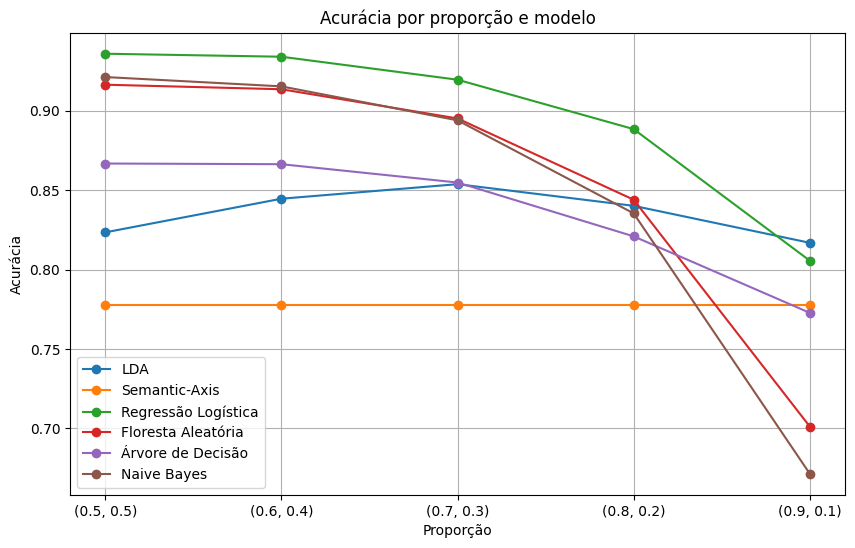

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Supondo que o df já esteja carregado

plt.figure(figsize=(10,6))

for modelo in df_resultados['modelo'].unique():
    subset = df_resultados[df_resultados['modelo'] == modelo]
    plt.plot(subset['prop'].astype(str), subset['acuracia'], marker='o', label=modelo)

plt.xlabel("Proporção")
plt.ylabel("Acurácia")
plt.title("Acurácia por proporção e modelo")
plt.legend()
plt.grid(True)

plt.show()

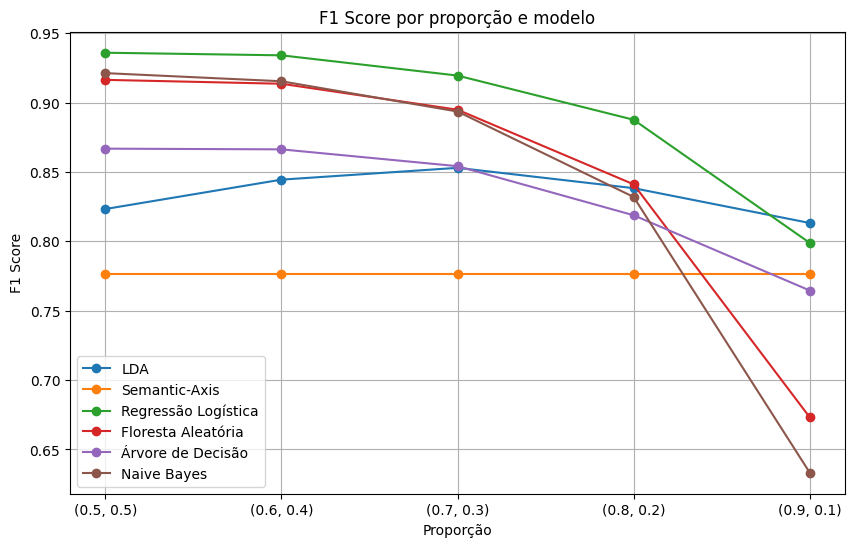

In [41]:
plt.figure(figsize=(10,6))

for modelo in df_resultados['modelo'].unique():
    subset = df_resultados[df_resultados['modelo'] == modelo]
    plt.plot(subset['prop'].astype(str), subset['f1'], marker='o', label=modelo)

plt.xlabel("Proporção")
plt.ylabel("F1 Score")
plt.title("F1 Score por proporção e modelo")
plt.legend()
plt.grid(True)

plt.show()

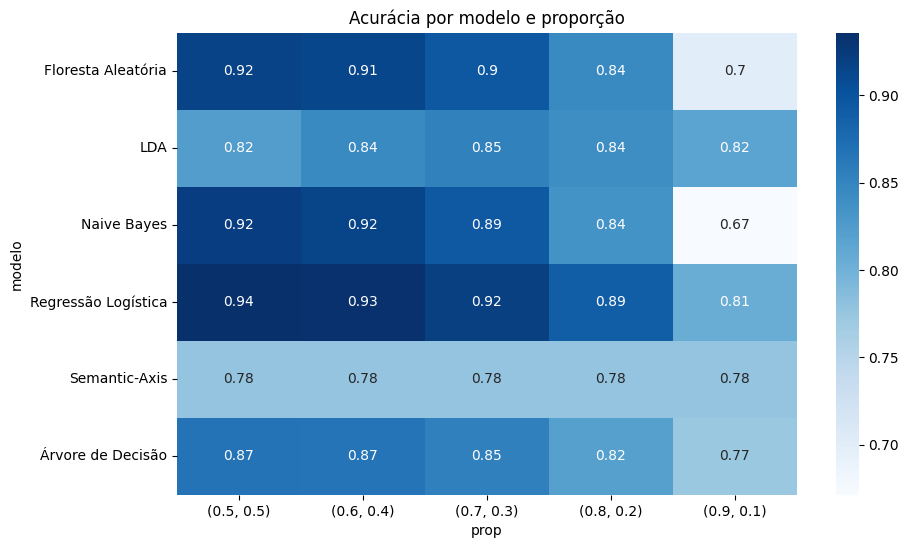

In [44]:
import seaborn as sns

pivot = df_resultados.pivot(index="modelo", columns="prop", values="acuracia")

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap="Blues")

plt.title("Acurácia por modelo e proporção")
plt.show()